In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import scipy.stats as stats
import statsmodels.api as sm
import ast

In [92]:
with open('/Users/ainsleylewis/Documents/Astronomy/LensSuite/results.dat', 'r') as f:
    header_line = f.readline().strip()

cols = header_line.split('\t')
if ' ' in cols[-1]:
    last_cols = cols[-1].split()
    cols = cols[:-1] + last_cols

df = pd.read_csv('/Users/ainsleylewis/Documents/Astronomy/LensSuite/results.dat', sep='\t', skiprows=1, names=cols, engine='python')

# ------------------------------------------------------------
# 2. Safely extract source_z from Source_Params column
# ------------------------------------------------------------
def safe_literal_eval(val):
    if pd.isna(val) or val == 'None':
        return None
    try:
        return ast.literal_eval(val)
    except:
        return None

df['Source_Params'] = df['Source_Params'].apply(safe_literal_eval)

def extract_source_z(params):
    if params is None or not isinstance(params, list) or len(params) == 0:
        return np.nan
    inner = params[0]
    if isinstance(inner, list) and len(inner) > 0:
        return inner[0]          # first element = source_z
    return np.nan

def extract_vel_disp(params):
    if params is None:
        return np.nan
    if isinstance(params, str):
        try:
            params = ast.literal_eval(params)   # convert string to dict
        except:
            return np.nan
    if isinstance(params, dict) and 'sie' in params:
        lst = params['sie']
        return lst[0] if lst else np.nan
    return np.nan

df['source_z'] = df['Source_Params'].apply(extract_source_z)
df['vel_disp'] = df['Lens_Params'].apply(extract_vel_disp)

# Z_Lens is already present
df['lens_z'] = df['Z_Lens']

# Clean Chi2
df['Chi2'] = pd.to_numeric(df['Chi2'], errors='coerce')

# Clean POS RMS
df['Pos_RMS'] = pd.to_numeric(df['Pos_RMS'], errors='coerce')

# Clean Mag Rms
df['Mag_RMS'] = pd.to_numeric(df['Mag_RMS'], errors='coerce')

In [93]:
df

,System,Z_Lens,Chi2,Pos_RMS,Mag_RMS,Avg_Flux_Err_%,Lens_Params,Source_Params,TD_RMS,No_Z_Lens_Flag,source_z,vel_disp,lens_z
0,2M1134,0.6600,5.419925e+01,0.018153,0.409526,1.033449e+02,"{'sie': [332.0153, 1.11609, 1.650969, 0.895426...","[[2.77, 1.242003, 1.375761]]",NaN,False,2.770,332.0153,0.6600
1,B2045,0.5000,1.797313e+00,0.003335,2.285680,5.414643e+02,"{'sie': [254.6724, 0.7156771, 1.147243, 0.5962...","[[1.56, 0.7647274, 0.846935]]",NaN,True,1.560,254.6724,0.5000
2,GRAL1131,0.4720,2.348431e+01,0.012316,11.218549,4.850514e+02,"{'sie': [246.695, -0.07995985, 0.7754883, 0.17...","[[1.09, -0.1083952, 0.8157753]]",NaN,False,1.090,246.6950,0.4720
3,H1413,0.5000,7.922232e+01,0.022347,1.734008,3.049018e+02,"{'sie': [180.2418, 0.1857577, 0.5697178, 0.474...","[[2.56, 0.1590461, 0.5306095]]",NaN,True,2.560,180.2418,0.5000
4,HE0435,0.4600,6.946708e-01,0.002074,2.707941,3.935408e+02,"{'sie': [260.5276, -1.16911, -0.5994581, 0.362...","[[1.69, -1.180773, -0.52478]]",NaN,False,1.690,260.5276,0.4600
5,HE1113,0.7500,8.134182e-01,0.002254,6.461680,8.828960e+02,"{'sie': [192.4808, -0.3173236, 0.1464006, 0.20...","[[1.24, -0.3062179, 0.1527568]]",NaN,False,1.240,192.4808,0.7500
6,HS0810,0.5000,5.620900e+00,0.539619,60899.688277,2.681199e+06,"{'sie': [174.0323, 0.02830443, -0.04126128, 4....","[[1.506, 0.02830462, -0.04126891]]",NaN,True,1.506,174.0323,0.5000
7,J0245,0.5000,7.125687e-07,0.000000,5.668652,6.807122e+02,"{'sie': [244.0289, -0.3432088, 0.435723, 0.179...","[[1.54, -0.342332, 0.4365156]]",NaN,True,1.540,244.0289,0.5000
8,J0246,0.5000,2.197422e-06,0.000000,1.755083,3.259819e+02,"{'sie': [173.1058, 0.01098265, 0.2107175, 0.30...","[[1.86, 0.01112122, 0.2107268]]",NaN,True,1.860,173.1058,0.5000
9,J0248,0.5000,6.610625e+02,0.071280,2.721057,3.207271e+02,"{'sie': [201.3599, -0.3992003, 0.8522451, 0.38...","[[2.43, -0.3661784, 0.7742372]]",NaN,False,2.430,201.3599,0.5000


In [94]:
# Create a Masked DataFrame for systems with No_Z_Lens_Flag = False
mask = df['No_Z_Lens_Flag'] == False
df_masked = df[mask]

In [95]:
# Add a total redshift column
df['total_z'] = df['source_z'] + df['lens_z']

In [96]:
# Check the info.dat files and extract line 4 
for i in range(len(df)):
    system_name = df.loc[i, 'System']
    info_file_path = f'/Users/ainsleylewis/Documents/Astronomy/LensSuite/{system_name}/info.dat'
    try:
        with open(info_file_path, 'r') as f:
            lines = f.readlines()
            if len(lines) >= 4:
                line_4 = lines[3].strip()
                # Extract the value after 'Pos + Flux Source = ' and convert to string
                if line_4.startswith('Pos + Flux Source = '):
                    pos_flux_value = line_4.split('=')[1].strip()
                    print(f'{system_name}: Pos + Flux Source = {pos_flux_value}')
                    df.loc[i, 'value_ref'] = pos_flux_value  # Store in DataFrame
            else:
                print(f'{system_name}: info.dat does not have 4 lines')
    except FileNotFoundError:
        print(f'{system_name}: info.dat not found')


2M1134: Pos + Flux Source = Keely et al (2025)
B2045: Pos + Flux Source = Keely et al (2025)
GRAL1131: Pos + Flux Source = Keely et al (2025)
H1413: Pos + Flux Source = Keely et al (2025)
HE0435: Pos + Flux Source = Keely et al (2025)
HE1113: Pos + Flux Source = Keely et al (2025)
HS0810: Pos + Flux Source = Neirenberg et al (2019) + Jones el al (2019)
J0245: Pos + Flux Source = Lemon et al (2020)
J0246: Pos + Flux Source = Lemon et al (2020)
J0248: Pos + Flux Source = Keely et al (2025)
J0259: Pos + Flux Source = Keely et al (2025)
J0457: Pos + Flux Source = Keely et al (2025)
J0607: Pos + Flux Source = Keely et al (2025)
J0608: Pos + Flux Source = Keely et al (2025)
J0659: Pos + Flux Source = Keely et al (2025)
J0803: Pos + Flux Source = Keely et al (2025)
J0924: Pos + Flux Source = Keely et al (2025)
J1042: Pos + Flux Source = Keely et al (2025)
J1251: Pos + Flux Source = Keely et al (2025)
J1537: Pos + Flux Source = Keely et al (2025)
J2017: Pos + Flux Source = Keely et al (2025)
J

In [97]:
# Show counts for all unique values in the value_ref column
print(df['value_ref'].value_counts())

value_ref
Keely et al (2025)                              25
Neirenberg et al (2019)                          4
Lemon et al (2020)                               2
Neirenberg et al (2019) + Jones el al (2019)     1
CASTLES                                          1
C Faure et al (2022)                             1
Name: count, dtype: int64


In [98]:
# Mask out the warm dusty quasars (only Keely et al (2025))
mask_dusty_quasars = df['value_ref'] == 'Keely et al (2025)'
df_dusty_quasars = df[mask_dusty_quasars]

=== lens_z vs Pos_RMS: Linear Regression Results ===
Slope: 0.0046 ± 0.1017
Intercept: 0.0381
R-squared: 0.0001
P-value (slope = 0): 9.64e-01


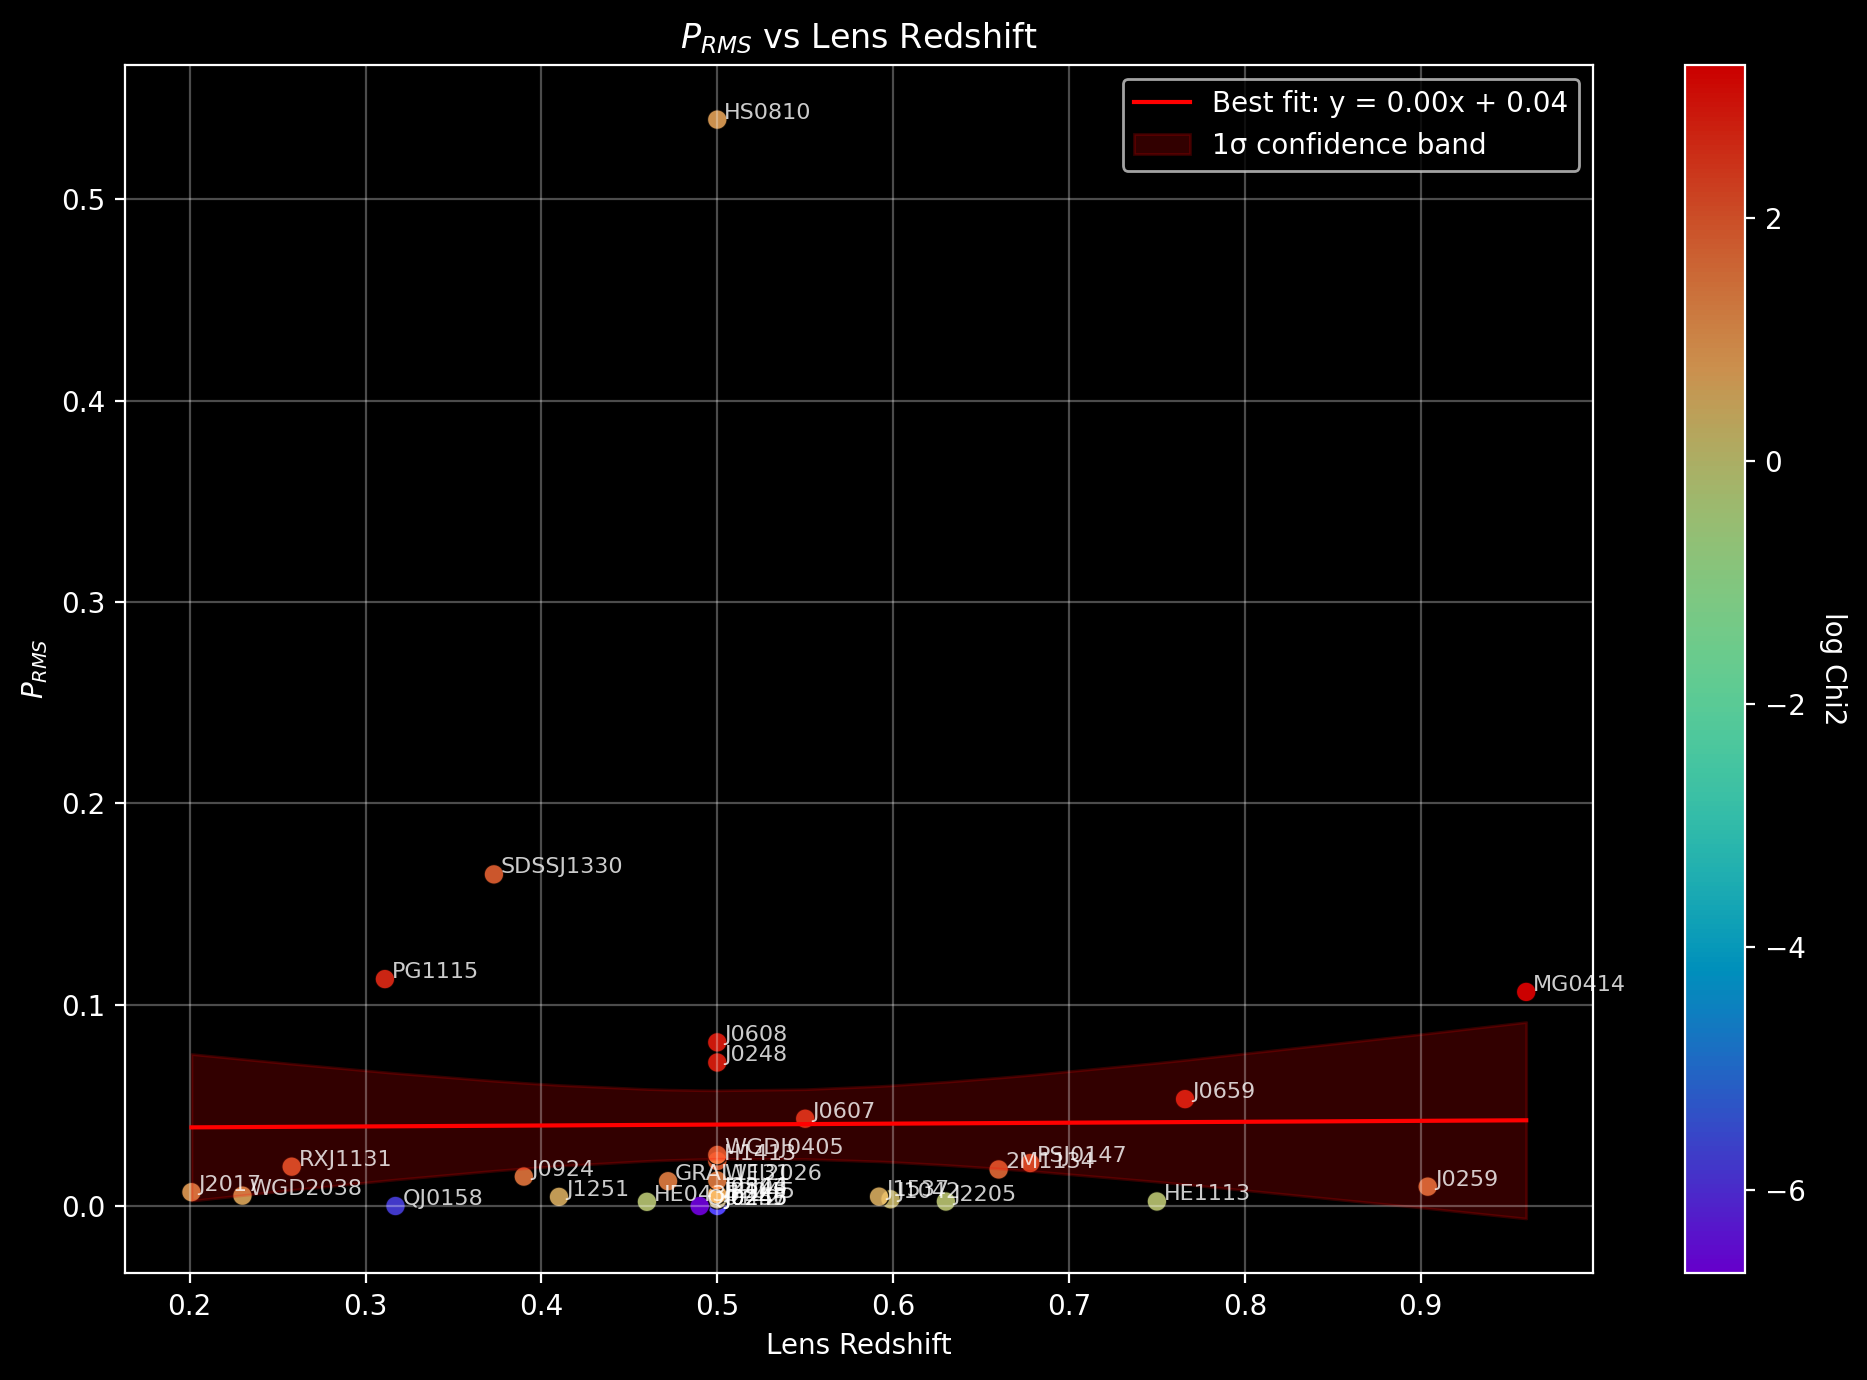

In [99]:
plot_df = df[['System', 'lens_z', 'Pos_RMS', 'Chi2']].dropna()
plot_df = plot_df[np.isfinite(plot_df['Chi2'])]
plot_df = plot_df[np.isfinite(plot_df['Pos_RMS'])]
plot_df = plot_df[np.isfinite(plot_df['lens_z'])]

x = plot_df['lens_z'].values
y = plot_df['Pos_RMS'].values
chi2 = plot_df['Chi2'].values
systems = plot_df['System'].values
log_chi2 = np.log10(chi2)


slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

print("=== lens_z vs Pos_RMS: Linear Regression Results ===")
print(f"Slope: {slope:.4f} ± {std_err:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"P-value (slope = 0): {p_value:.2e}")

# Statsmodels for confidence band
X_sm = sm.add_constant(x)
model = sm.OLS(y, X_sm).fit()
pred = model.get_prediction(X_sm)
conf_int = pred.conf_int(alpha=0.32)   # 68% CI
idx = np.argsort(x)
x_sorted = x[idx]
y_fit = model.predict(X_sm)[idx]
conf_lower = conf_int[idx, 0]
conf_upper = conf_int[idx, 1]

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))
sc = plt.scatter(x, y, c=log_chi2, cmap='rainbow', alpha=0.8, s=50, edgecolors='k', linewidth=0.5)
cbar = plt.colorbar(sc)
cbar.set_label('log Chi2', rotation=270, labelpad=15)

for xi, yi, name in zip(x, y, systems):
    plt.text(xi + 0.004, yi + 0.0005, name, fontsize=8, alpha=0.8)

plt.plot(x_sorted, y_fit, 'r-', label=f'Best fit: y = {slope:.2f}x + {intercept:.2f}')
plt.fill_between(x_sorted, conf_lower, conf_upper, color='red', alpha=0.2, label='1σ confidence band')

plt.xlabel('Lens Redshift')
plt.ylabel('$P_{RMS}$')
plt.title('$P_{RMS}$ vs Lens Redshift')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== lens_z vs Pos_RMS: Linear Regression Results ===
Slope: 0.0255 ± 0.0388
Intercept: 0.0114
R-squared: 0.0184
P-value (slope = 0): 5.18e-01


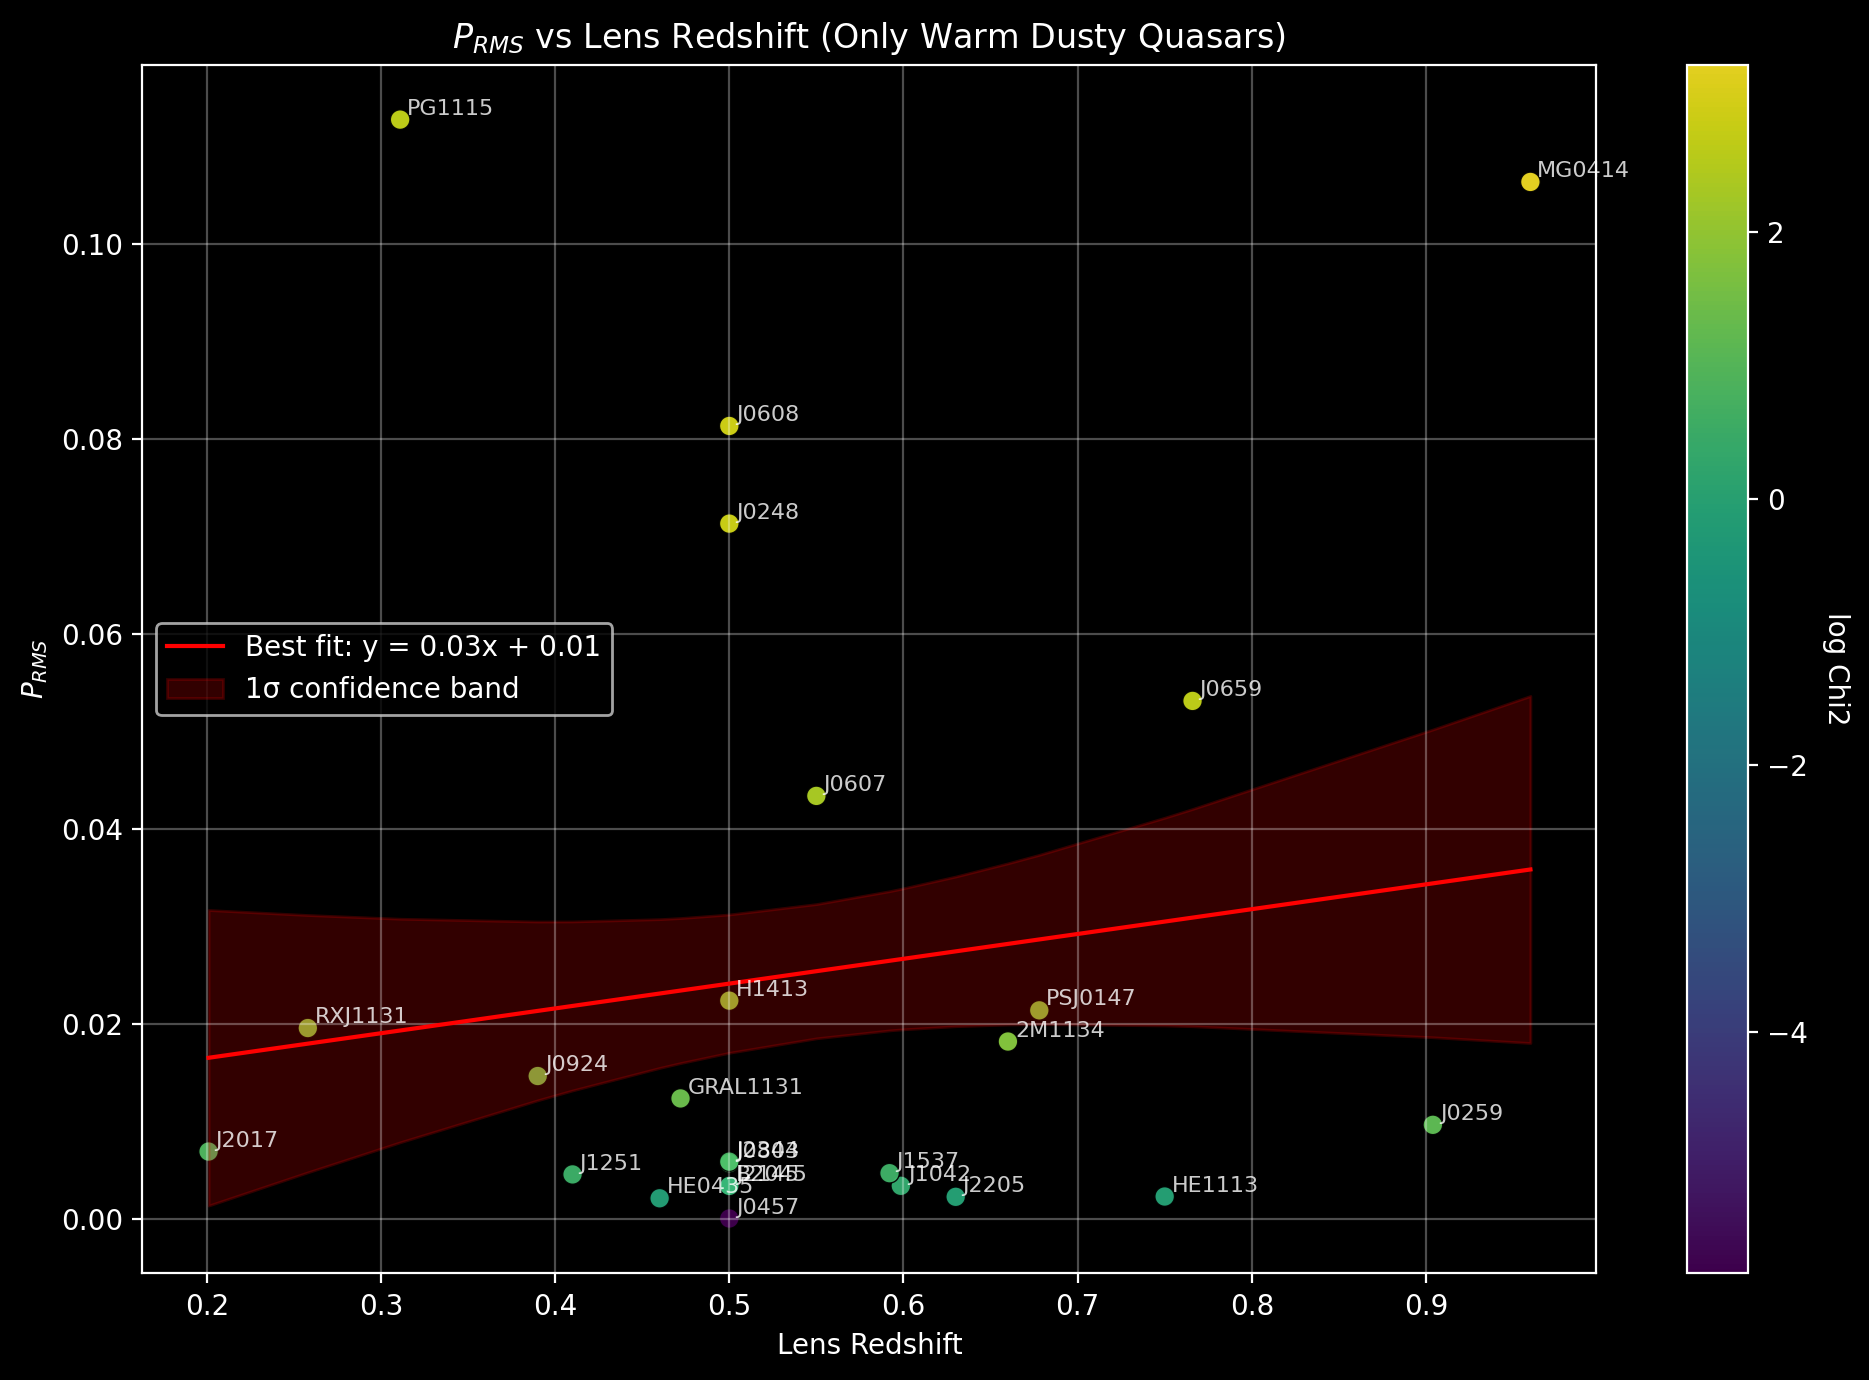

In [119]:
plot_df = df_dusty_quasars[['System', 'lens_z', 'Pos_RMS', 'Chi2']].dropna()
plot_df = plot_df[np.isfinite(plot_df['Chi2'])]
plot_df = plot_df[np.isfinite(plot_df['Pos_RMS'])]
plot_df = plot_df[np.isfinite(plot_df['lens_z'])]

x = plot_df['lens_z'].values
y = plot_df['Pos_RMS'].values
chi2 = plot_df['Chi2'].values
systems = plot_df['System'].values
log_chi2 = np.log10(chi2)


slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

print("=== lens_z vs Pos_RMS: Linear Regression Results ===")
print(f"Slope: {slope:.4f} ± {std_err:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"P-value (slope = 0): {p_value:.2e}")

# Statsmodels for confidence band
X_sm = sm.add_constant(x)
model = sm.OLS(y, X_sm).fit()
pred = model.get_prediction(X_sm)
conf_int = pred.conf_int(alpha=0.32)   # 68% CI
idx = np.argsort(x)
x_sorted = x[idx]
y_fit = model.predict(X_sm)[idx]
conf_lower = conf_int[idx, 0]
conf_upper = conf_int[idx, 1]

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))
sc = plt.scatter(x, y, c=log_chi2, cmap='viridis', alpha=0.9, s=50, edgecolors='k', linewidth=0.5)
cbar = plt.colorbar(sc)
cbar.set_label('log Chi2', rotation=270, labelpad=15)

for xi, yi, name in zip(x, y, systems):
    plt.text(xi + 0.004, yi + 0.0005, name, fontsize=8, alpha=0.8)

plt.plot(x_sorted, y_fit, 'r-', label=f'Best fit: y = {slope:.2f}x + {intercept:.2f}')
plt.fill_between(x_sorted, conf_lower, conf_upper, color='red', alpha=0.2, label='1σ confidence band')

plt.xlabel('Lens Redshift')
plt.ylabel('$P_{RMS}$')
plt.title('$P_{RMS}$ vs Lens Redshift (Only Warm Dusty Quasars)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== lens_z vs Pos_RMS: Linear Regression Results ===
Slope: 0.0099 ± 0.0476
Intercept: 0.0256
R-squared: 0.0022
P-value (slope = 0): 8.37e-01


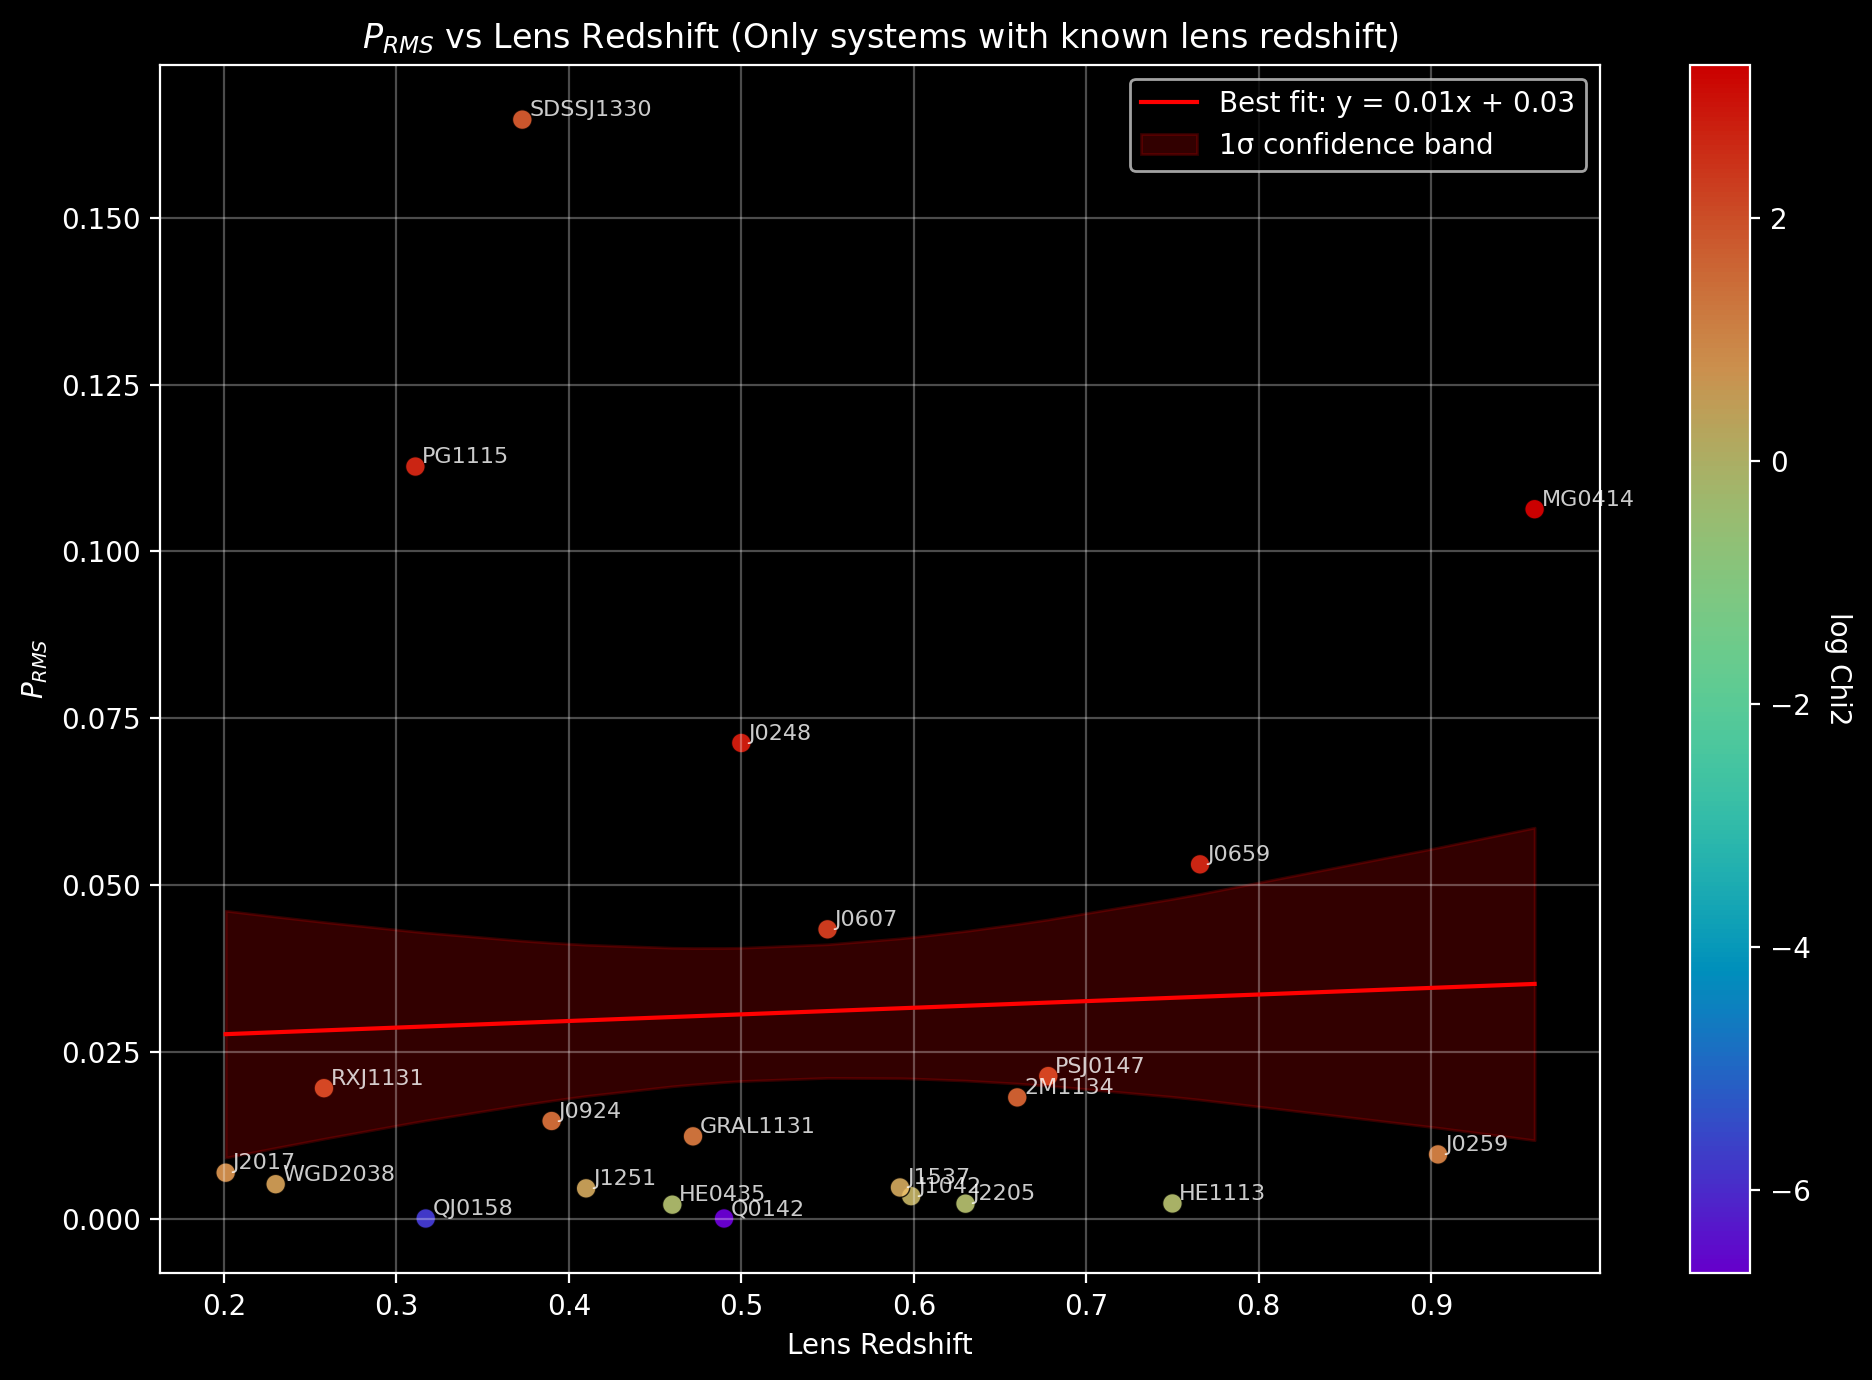

In [101]:
plot_df = df_masked[['System', 'lens_z', 'Pos_RMS', 'Chi2']].dropna()
plot_df = plot_df[np.isfinite(plot_df['Chi2'])]
plot_df = plot_df[np.isfinite(plot_df['Pos_RMS'])]
plot_df = plot_df[np.isfinite(plot_df['lens_z'])]

x = plot_df['lens_z'].values
y = plot_df['Pos_RMS'].values
chi2 = plot_df['Chi2'].values
systems = plot_df['System'].values
log_chi2 = np.log10(chi2)


slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

print("=== lens_z vs Pos_RMS: Linear Regression Results ===")
print(f"Slope: {slope:.4f} ± {std_err:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"P-value (slope = 0): {p_value:.2e}")

# Statsmodels for confidence band
X_sm = sm.add_constant(x)
model = sm.OLS(y, X_sm).fit()
pred = model.get_prediction(X_sm)
conf_int = pred.conf_int(alpha=0.32)   # 68% CI
idx = np.argsort(x)
x_sorted = x[idx]
y_fit = model.predict(X_sm)[idx]
conf_lower = conf_int[idx, 0]
conf_upper = conf_int[idx, 1]

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))
sc = plt.scatter(x, y, c=log_chi2, cmap='rainbow', alpha=0.8, s=50, edgecolors='k', linewidth=0.5)
cbar = plt.colorbar(sc)
cbar.set_label('log Chi2', rotation=270, labelpad=15)

for xi, yi, name in zip(x, y, systems):
    plt.text(xi + 0.004, yi + 0.0005, name, fontsize=8, alpha=0.8)

plt.plot(x_sorted, y_fit, 'r-', label=f'Best fit: y = {slope:.2f}x + {intercept:.2f}')
plt.fill_between(x_sorted, conf_lower, conf_upper, color='red', alpha=0.2, label='1σ confidence band')

plt.xlabel('Lens Redshift')
plt.ylabel('$P_{RMS}$')
plt.title('$P_{RMS}$ vs Lens Redshift (Only systems with known lens redshift)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== source_z vs Pos_RMS: Linear Regression Results ===
Slope: -0.0068 ± 0.0252
Intercept: 0.0533
R-squared: 0.0023
P-value (slope = 0): 7.88e-01


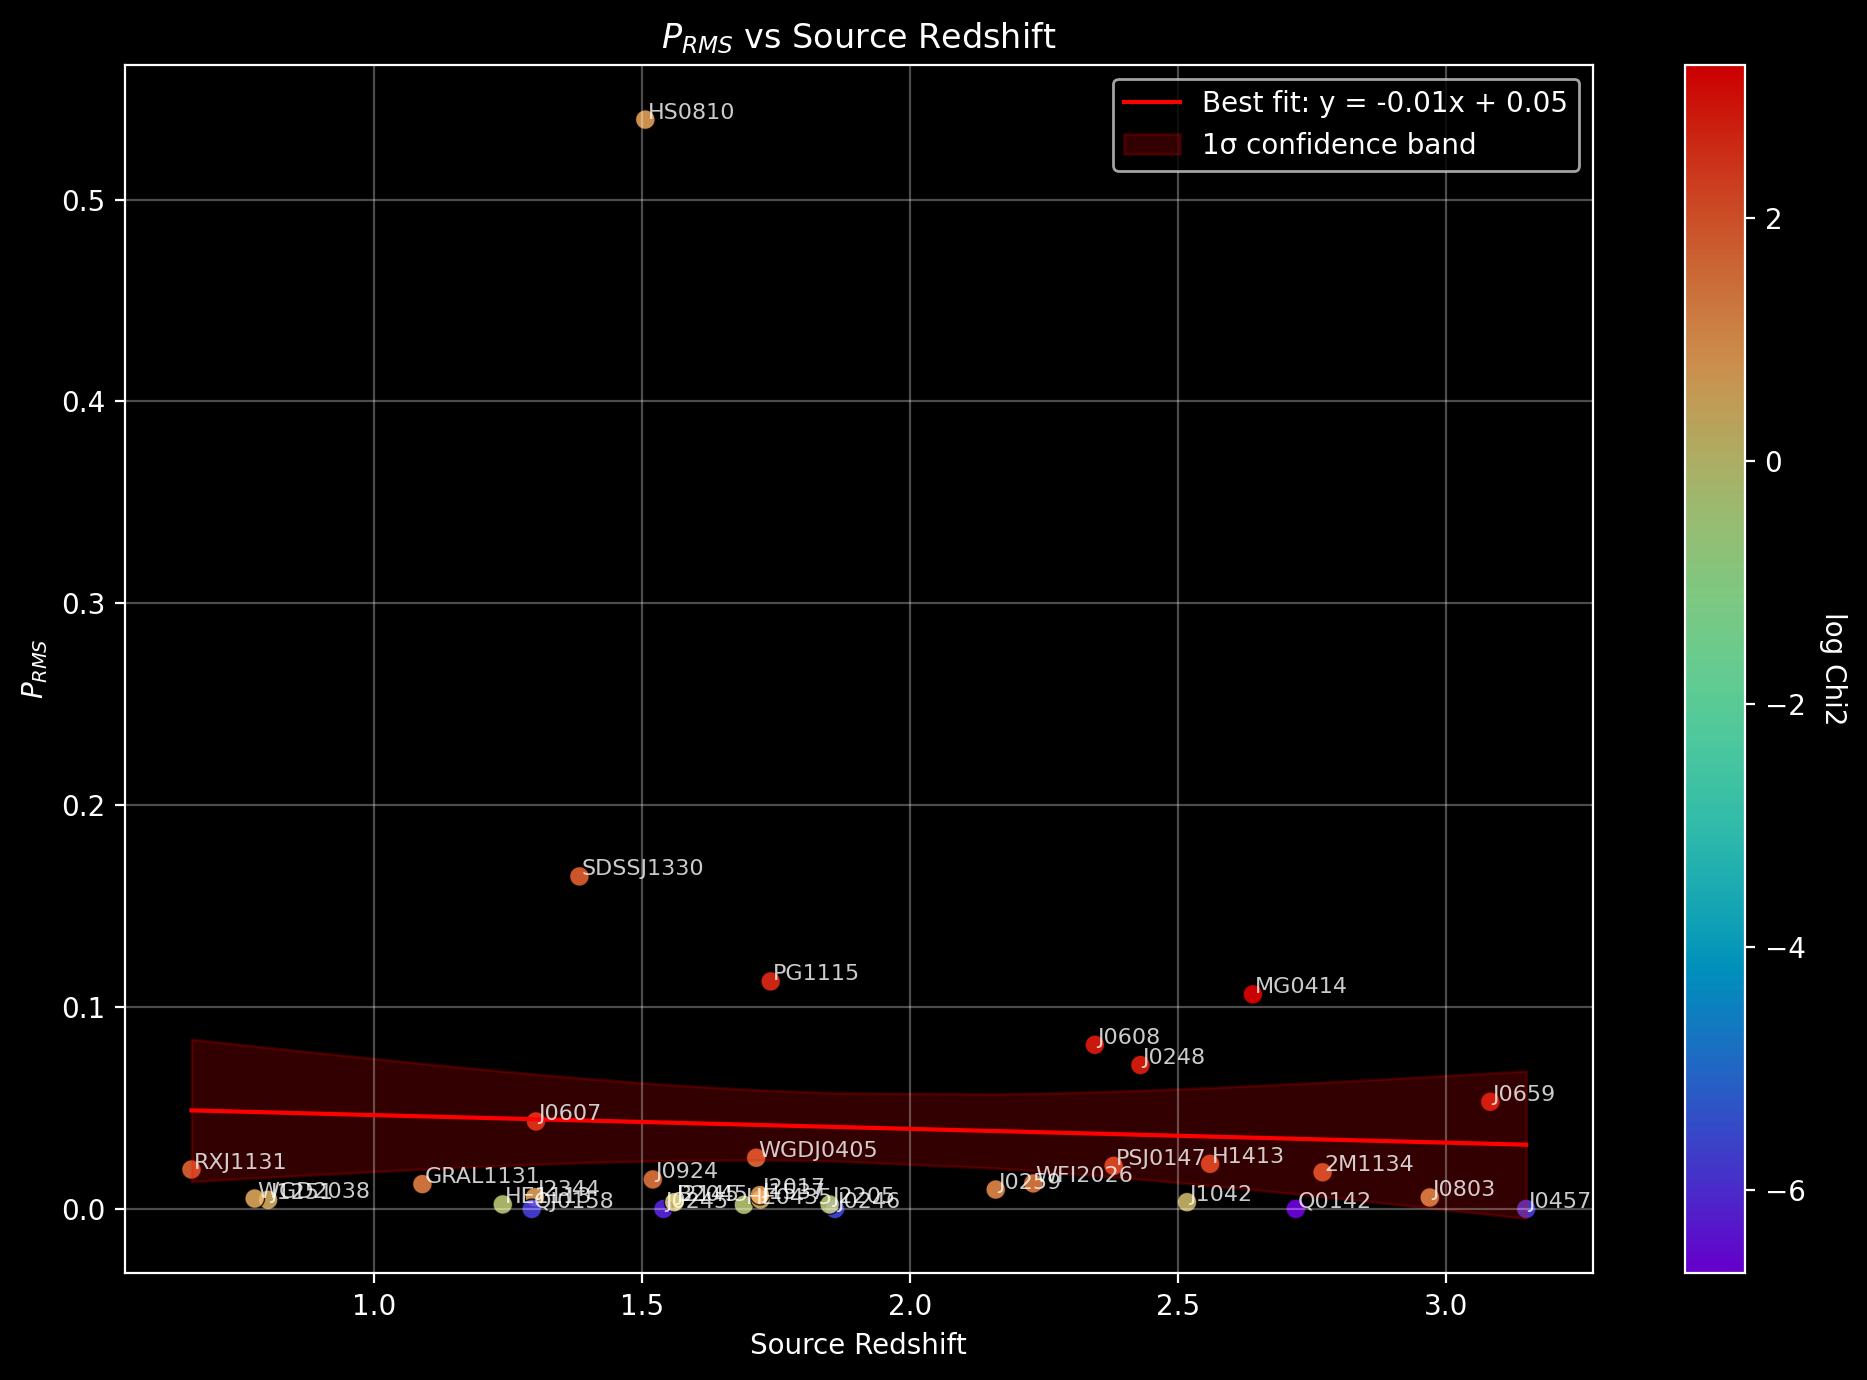

In [102]:
plot_df = df[['System', 'source_z', 'Pos_RMS', 'Chi2']].dropna()
plot_df = plot_df[np.isfinite(plot_df['Chi2'])]
plot_df = plot_df[np.isfinite(plot_df['Pos_RMS'])]
plot_df = plot_df[np.isfinite(plot_df['source_z'])]

x = plot_df['source_z'].values
y = plot_df['Pos_RMS'].values
chi2 = plot_df['Chi2'].values
systems = plot_df['System'].values
log_chi2 = np.log10(chi2)


slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

print("=== source_z vs Pos_RMS: Linear Regression Results ===")
print(f"Slope: {slope:.4f} ± {std_err:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"P-value (slope = 0): {p_value:.2e}")

# Statsmodels for confidence band
X_sm = sm.add_constant(x)
model = sm.OLS(y, X_sm).fit()
pred = model.get_prediction(X_sm)
conf_int = pred.conf_int(alpha=0.32)   # 68% CI
idx = np.argsort(x)
x_sorted = x[idx]
y_fit = model.predict(X_sm)[idx]
conf_lower = conf_int[idx, 0]
conf_upper = conf_int[idx, 1]

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))
sc = plt.scatter(x, y, c=log_chi2, cmap='rainbow', alpha=0.8, s=50, edgecolors='k', linewidth=0.5)
cbar = plt.colorbar(sc)
cbar.set_label('log Chi2', rotation=270, labelpad=15)

for xi, yi, name in zip(x, y, systems):
    plt.text(xi + 0.004, yi + 0.0005, name, fontsize=8, alpha=0.8)

plt.plot(x_sorted, y_fit, 'r-', label=f'Best fit: y = {slope:.2f}x + {intercept:.2f}')
plt.fill_between(x_sorted, conf_lower, conf_upper, color='red', alpha=0.2, label='1σ confidence band')

plt.xlabel('Source Redshift')
plt.ylabel('$P_{RMS}$')
plt.title('$P_{RMS}$ vs Source Redshift')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== source_z vs Pos_RMS: Linear Regression Results ===
Slope: 0.0093 ± 0.0140
Intercept: 0.0141
R-squared: 0.0217
P-value (slope = 0): 5.13e-01


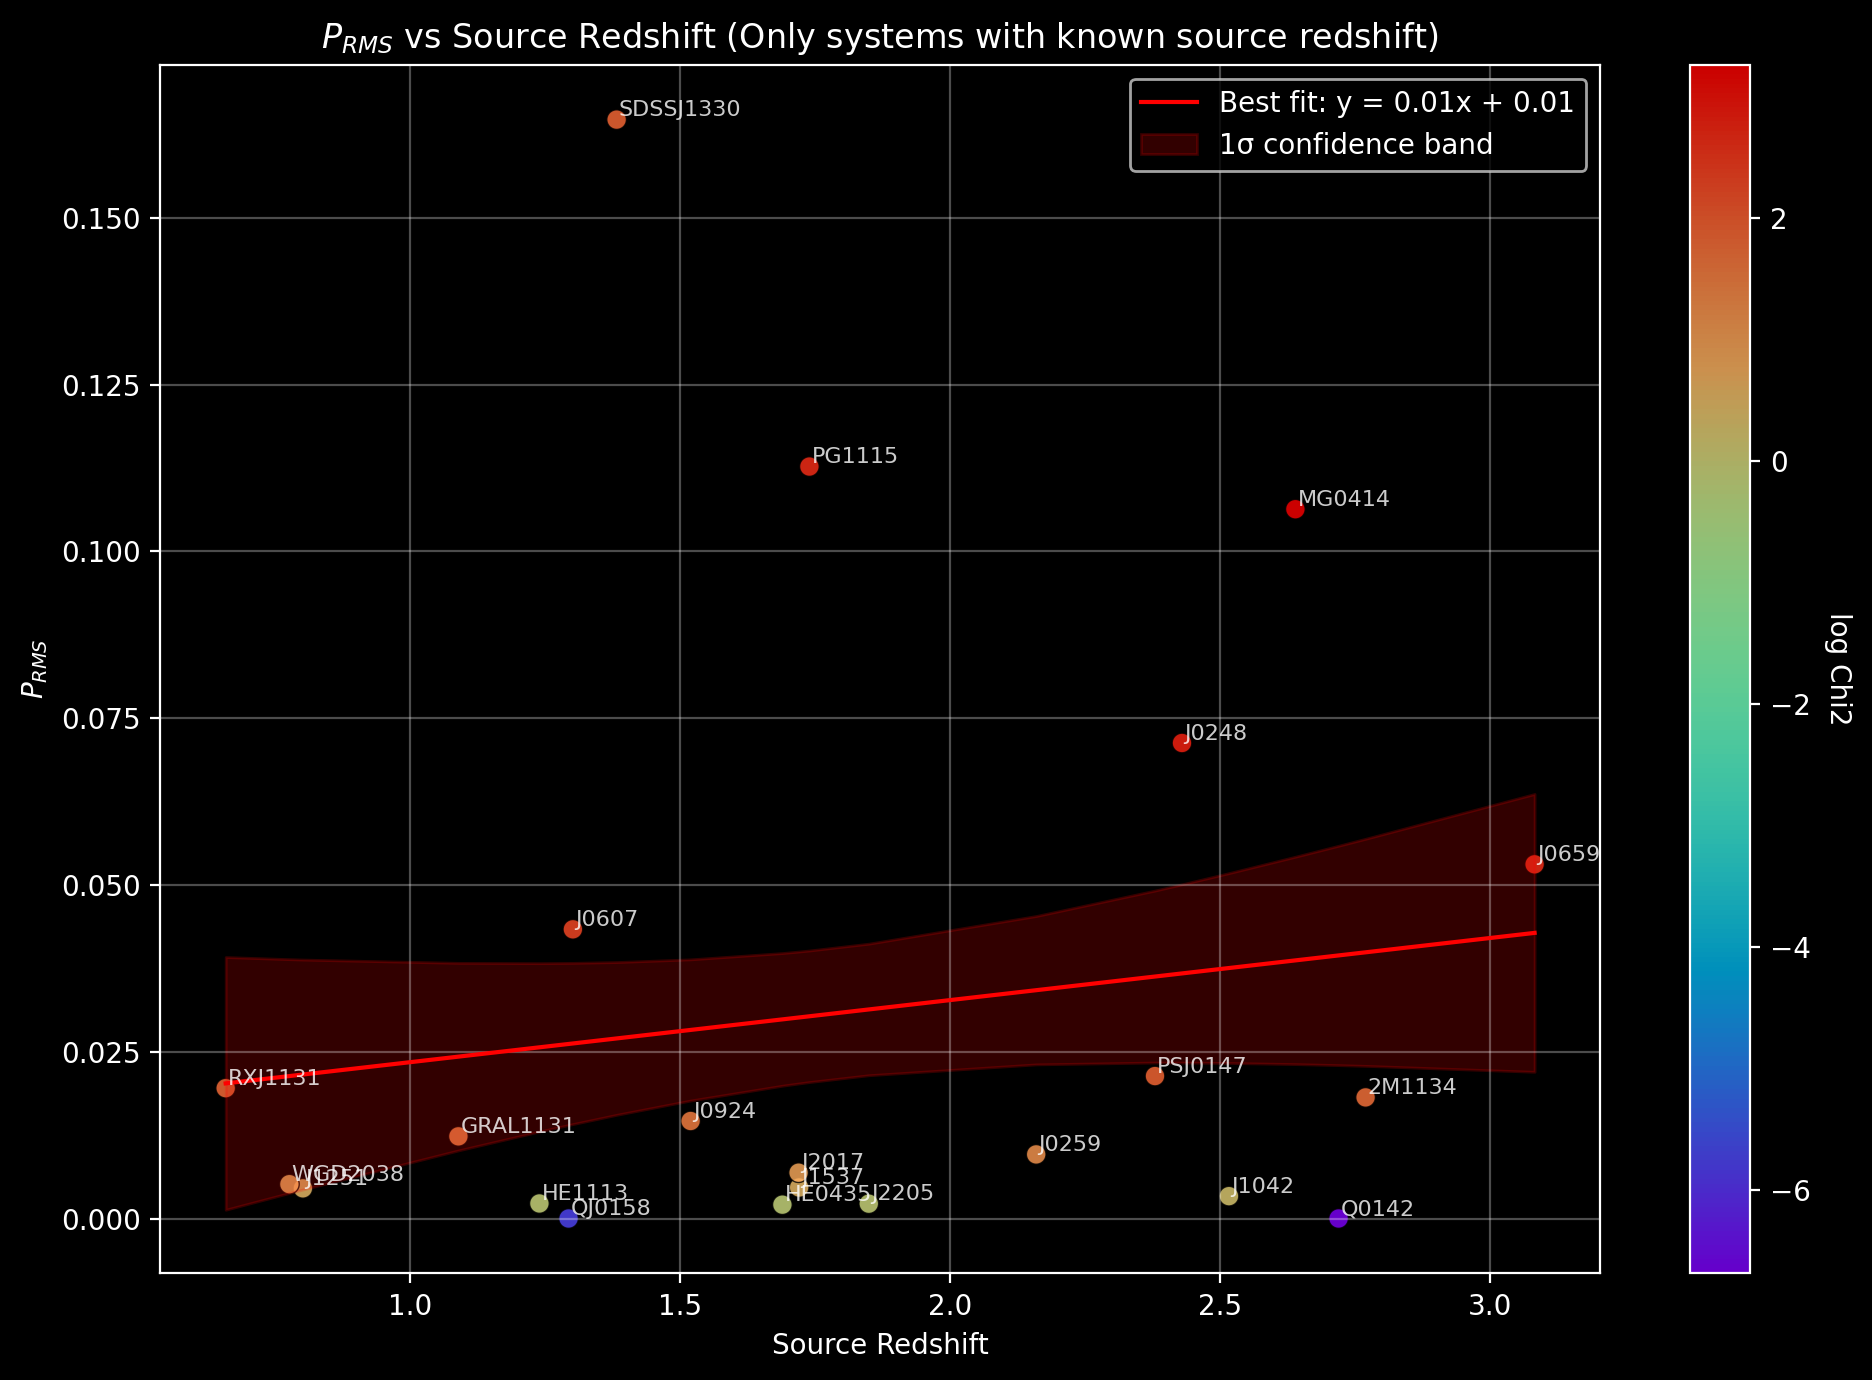

In [103]:
plot_df = df_masked[['System', 'source_z', 'Pos_RMS', 'Chi2']].dropna()
plot_df = plot_df[np.isfinite(plot_df['Chi2'])]
plot_df = plot_df[np.isfinite(plot_df['Pos_RMS'])]
plot_df = plot_df[np.isfinite(plot_df['source_z'])]

x = plot_df['source_z'].values
y = plot_df['Pos_RMS'].values
chi2 = plot_df['Chi2'].values
systems = plot_df['System'].values
log_chi2 = np.log10(chi2)


slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

print("=== source_z vs Pos_RMS: Linear Regression Results ===")
print(f"Slope: {slope:.4f} ± {std_err:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"P-value (slope = 0): {p_value:.2e}")

# Statsmodels for confidence band
X_sm = sm.add_constant(x)
model = sm.OLS(y, X_sm).fit()
pred = model.get_prediction(X_sm)
conf_int = pred.conf_int(alpha=0.32)   # 68% CI
idx = np.argsort(x)
x_sorted = x[idx]
y_fit = model.predict(X_sm)[idx]
conf_lower = conf_int[idx, 0]
conf_upper = conf_int[idx, 1]

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))
sc = plt.scatter(x, y, c=log_chi2, cmap='rainbow', alpha=0.8, s=50, edgecolors='k', linewidth=0.5)
cbar = plt.colorbar(sc)
cbar.set_label('log Chi2', rotation=270, labelpad=15)

for xi, yi, name in zip(x, y, systems):
    plt.text(xi + 0.004, yi + 0.0005, name, fontsize=8, alpha=0.8)

plt.plot(x_sorted, y_fit, 'r-', label=f'Best fit: y = {slope:.2f}x + {intercept:.2f}')
plt.fill_between(x_sorted, conf_lower, conf_upper, color='red', alpha=0.2, label='1σ confidence band')

plt.xlabel('Source Redshift')
plt.ylabel('$P_{RMS}$')
plt.title('$P_{RMS}$ vs Source Redshift (Only systems with known source redshift)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== total_z vs Pos_RMS: Linear Regression Results ===
Slope: -0.0050 ± 0.0220
Intercept: 0.0525
R-squared: 0.0016
P-value (slope = 0): 8.22e-01


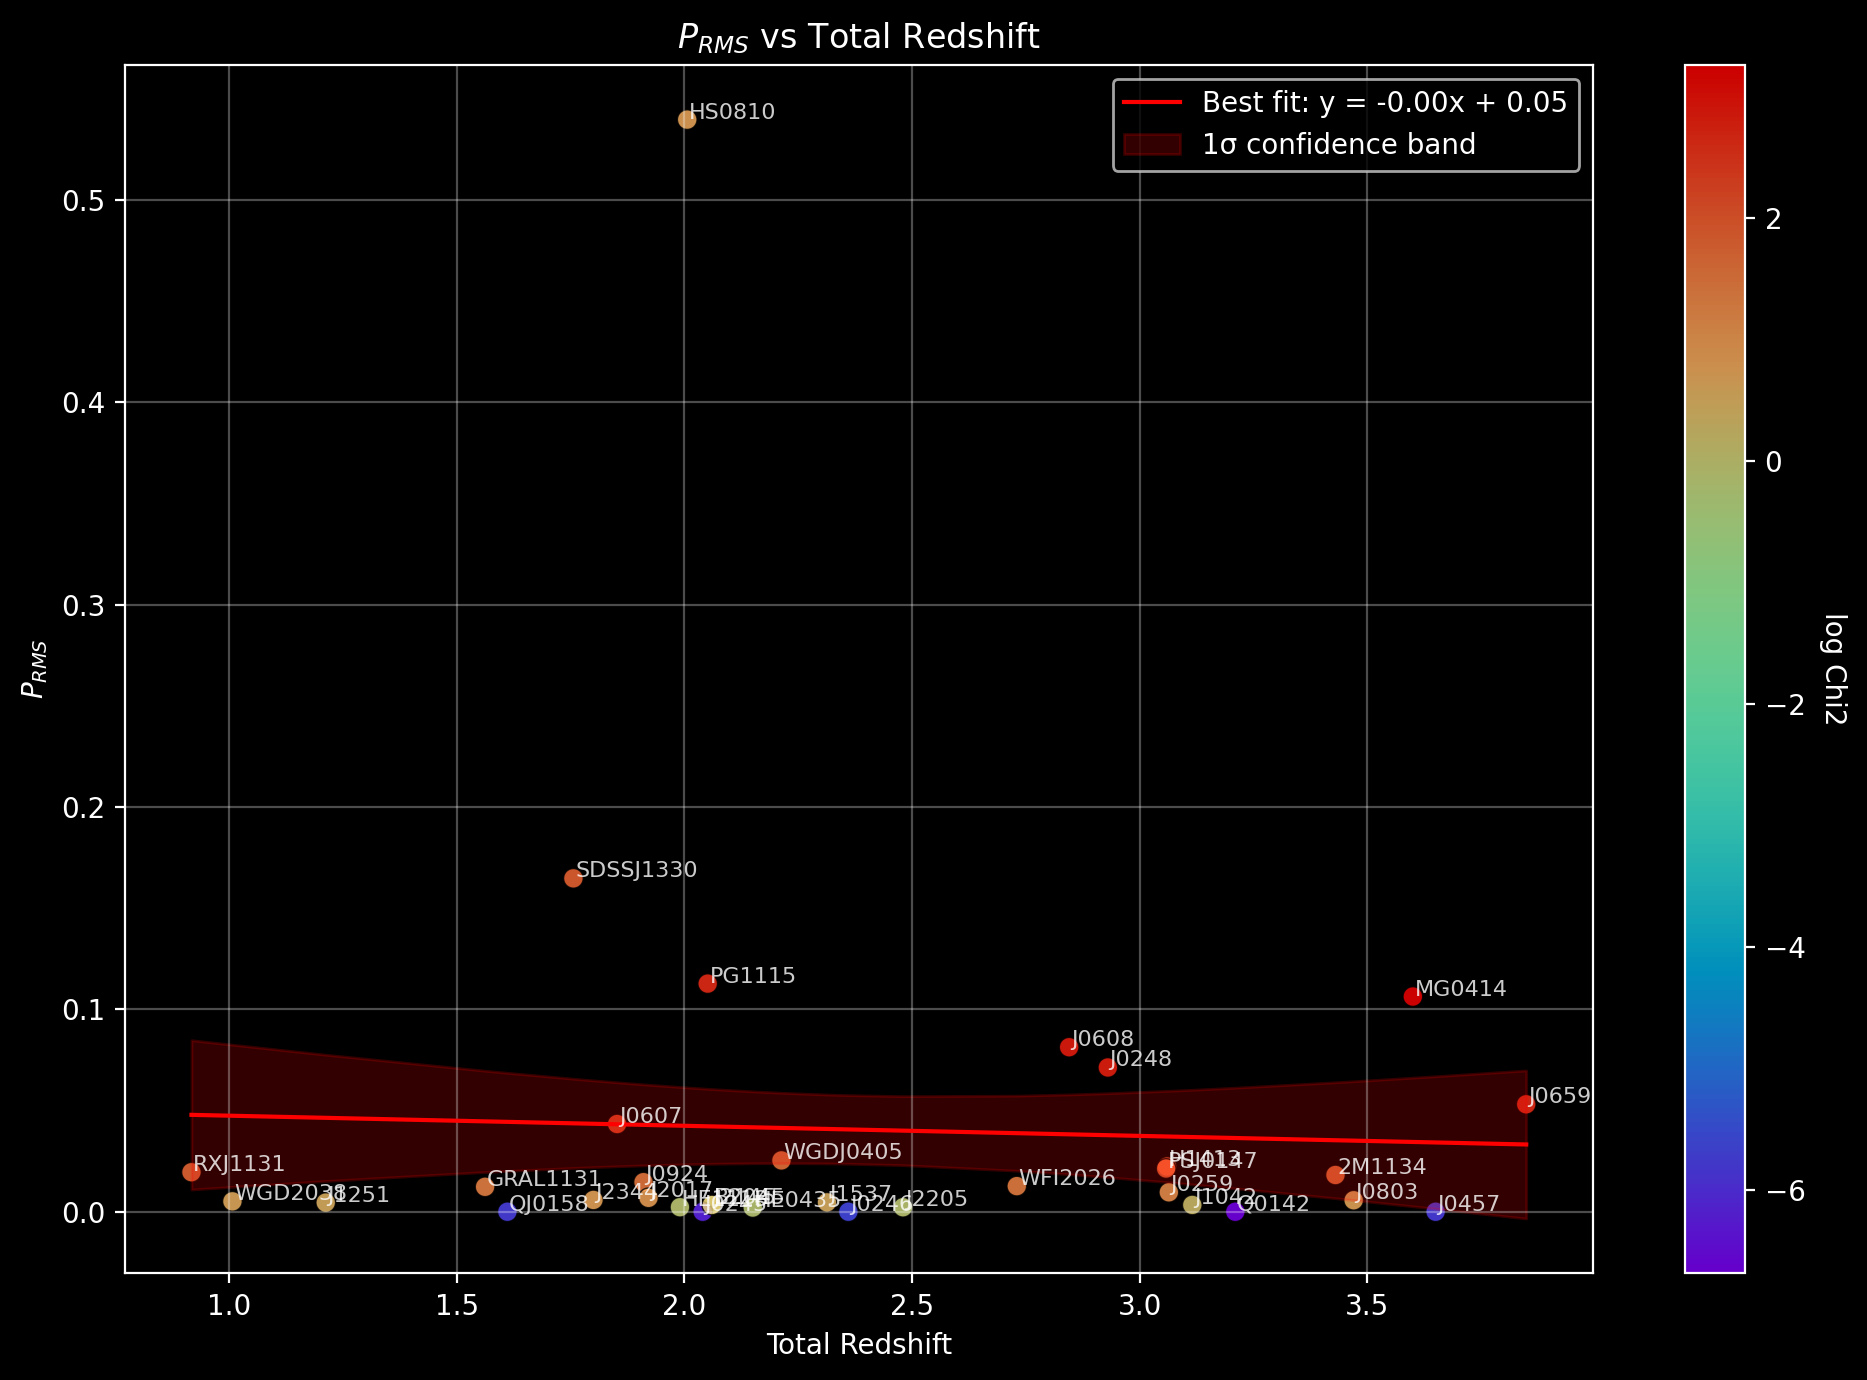

In [104]:
plot_df = df[['System', 'total_z', 'Pos_RMS', 'Chi2']].dropna()
plot_df = plot_df[np.isfinite(plot_df['Chi2'])]
plot_df = plot_df[np.isfinite(plot_df['Pos_RMS'])]
plot_df = plot_df[np.isfinite(plot_df['total_z'])]

x = plot_df['total_z'].values
y = plot_df['Pos_RMS'].values
chi2 = plot_df['Chi2'].values
systems = plot_df['System'].values
log_chi2 = np.log10(chi2)


slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

print("=== total_z vs Pos_RMS: Linear Regression Results ===")
print(f"Slope: {slope:.4f} ± {std_err:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"P-value (slope = 0): {p_value:.2e}")

# Statsmodels for confidence band
X_sm = sm.add_constant(x)
model = sm.OLS(y, X_sm).fit()
pred = model.get_prediction(X_sm)
conf_int = pred.conf_int(alpha=0.32)   # 68% CI
idx = np.argsort(x)
x_sorted = x[idx]
y_fit = model.predict(X_sm)[idx]
conf_lower = conf_int[idx, 0]
conf_upper = conf_int[idx, 1]

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))
sc = plt.scatter(x, y, c=log_chi2, cmap='rainbow', alpha=0.8, s=50, edgecolors='k', linewidth=0.5)
cbar = plt.colorbar(sc)
cbar.set_label('log Chi2', rotation=270, labelpad=15)

for xi, yi, name in zip(x, y, systems):
    plt.text(xi + 0.004, yi + 0.0005, name, fontsize=8, alpha=0.8)

plt.plot(x_sorted, y_fit, 'r-', label=f'Best fit: y = {slope:.2f}x + {intercept:.2f}')
plt.fill_between(x_sorted, conf_lower, conf_upper, color='red', alpha=0.2, label='1σ confidence band')

plt.xlabel('Total Redshift')
plt.ylabel('$P_{RMS}$')
plt.title('$P_{RMS}$ vs Total Redshift')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== total_z vs Pos_RMS: Linear Regression Results ===
Slope: 0.0101 ± 0.0084
Intercept: -0.0000
R-squared: 0.0587
P-value (slope = 0): 2.43e-01


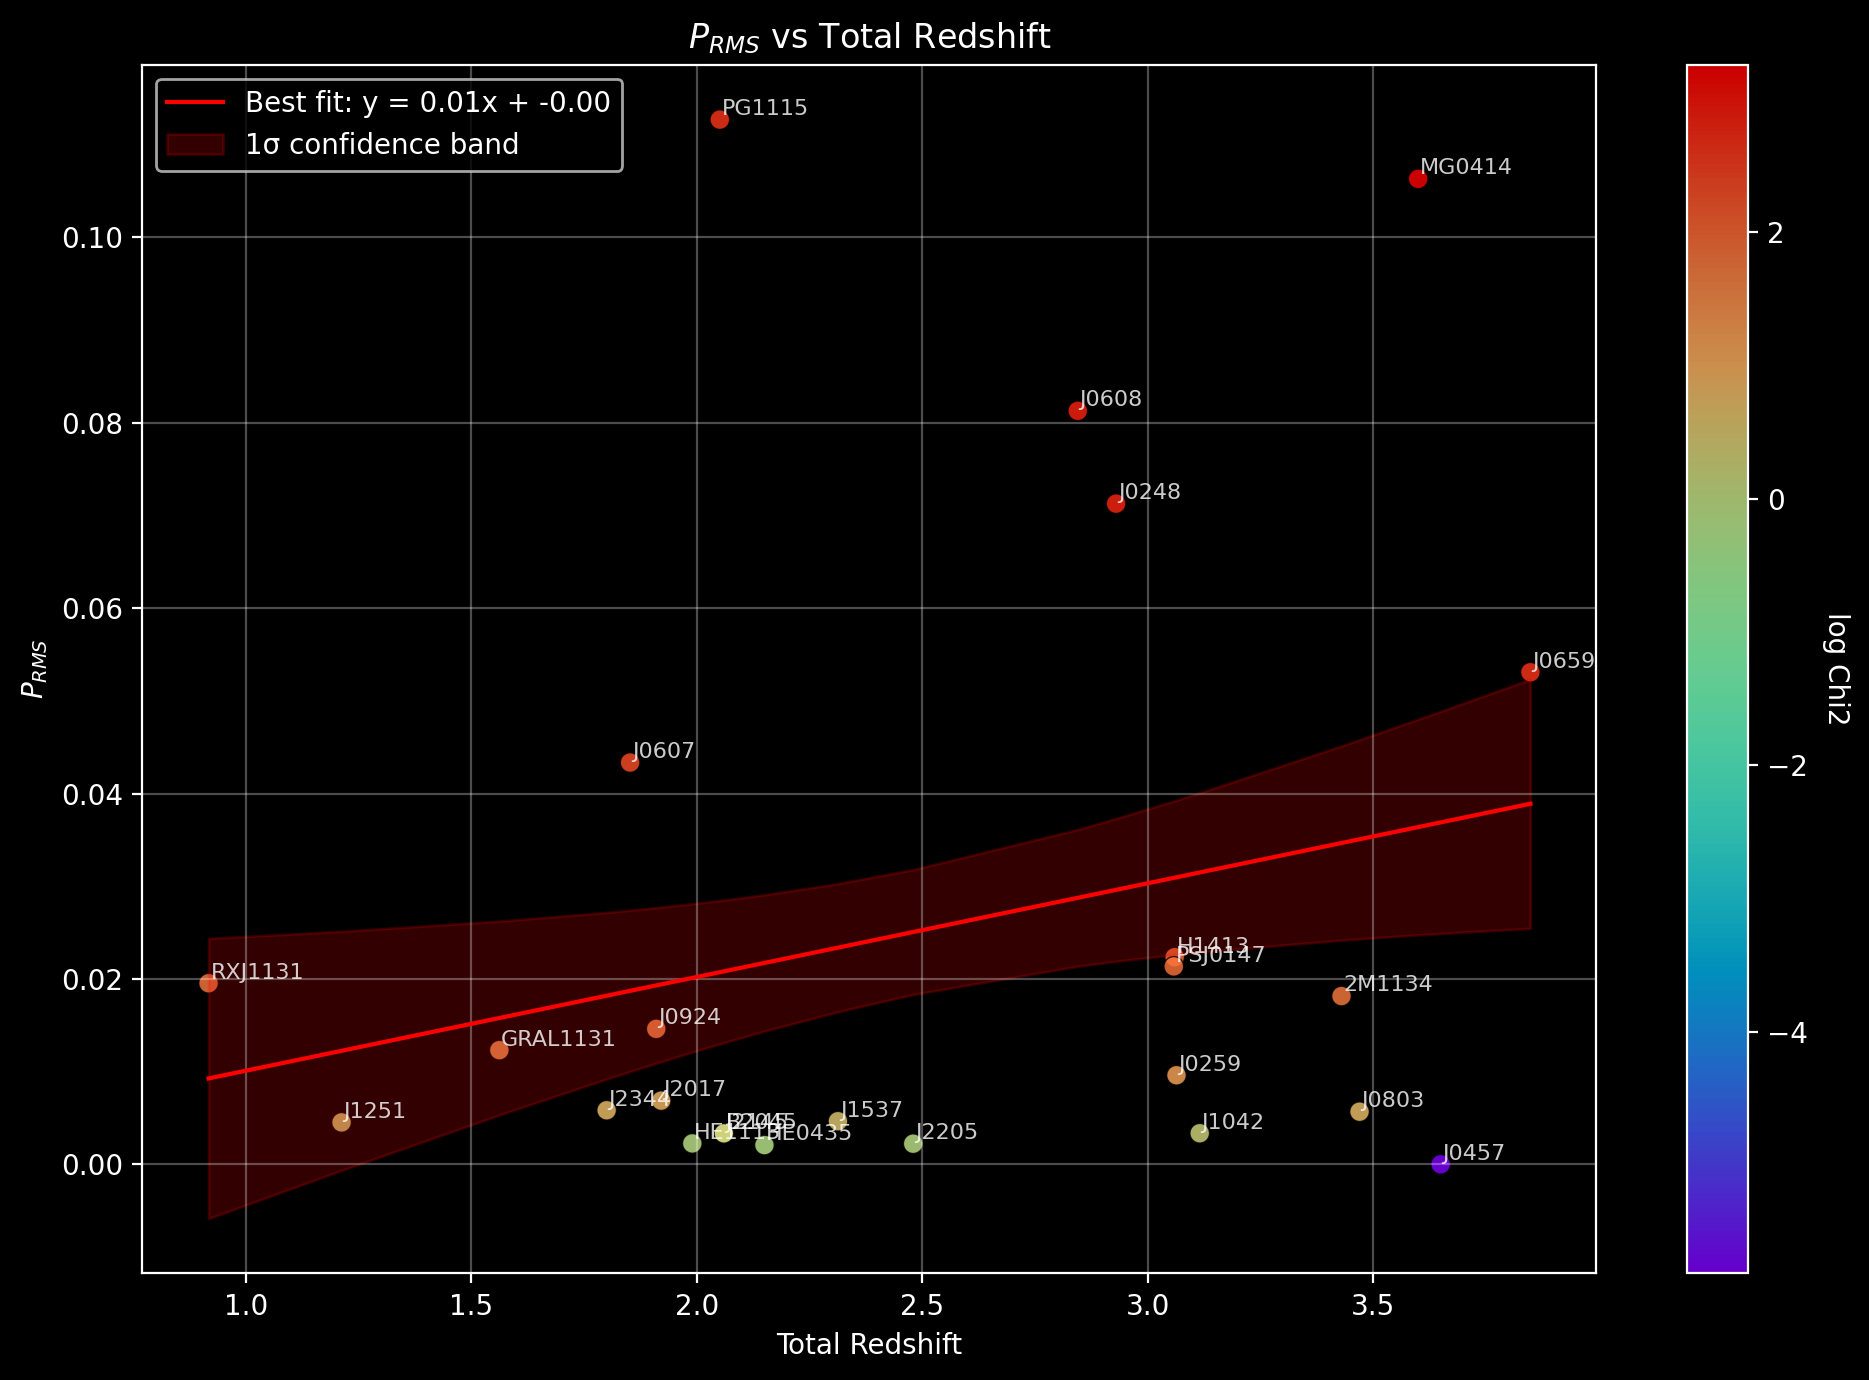

In [105]:
plot_df = df_dusty_quasars[['System', 'total_z', 'Pos_RMS', 'Chi2']].dropna()
plot_df = plot_df[np.isfinite(plot_df['Chi2'])]
plot_df = plot_df[np.isfinite(plot_df['Pos_RMS'])]
plot_df = plot_df[np.isfinite(plot_df['total_z'])]

x = plot_df['total_z'].values
y = plot_df['Pos_RMS'].values
chi2 = plot_df['Chi2'].values
systems = plot_df['System'].values
log_chi2 = np.log10(chi2)


slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

print("=== total_z vs Pos_RMS: Linear Regression Results ===")
print(f"Slope: {slope:.4f} ± {std_err:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"P-value (slope = 0): {p_value:.2e}")

# Statsmodels for confidence band
X_sm = sm.add_constant(x)
model = sm.OLS(y, X_sm).fit()
pred = model.get_prediction(X_sm)
conf_int = pred.conf_int(alpha=0.32)   # 68% CI
idx = np.argsort(x)
x_sorted = x[idx]
y_fit = model.predict(X_sm)[idx]
conf_lower = conf_int[idx, 0]
conf_upper = conf_int[idx, 1]

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))
sc = plt.scatter(x, y, c=log_chi2, cmap='rainbow', alpha=0.8, s=50, edgecolors='k', linewidth=0.5)
cbar = plt.colorbar(sc)
cbar.set_label('log Chi2', rotation=270, labelpad=15)

for xi, yi, name in zip(x, y, systems):
    plt.text(xi + 0.004, yi + 0.0005, name, fontsize=8, alpha=0.8)

plt.plot(x_sorted, y_fit, 'r-', label=f'Best fit: y = {slope:.2f}x + {intercept:.2f}')
plt.fill_between(x_sorted, conf_lower, conf_upper, color='red', alpha=0.2, label='1σ confidence band')

plt.xlabel('Total Redshift')
plt.ylabel('$P_{RMS}$')
plt.title('$P_{RMS}$ vs Total Redshift')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

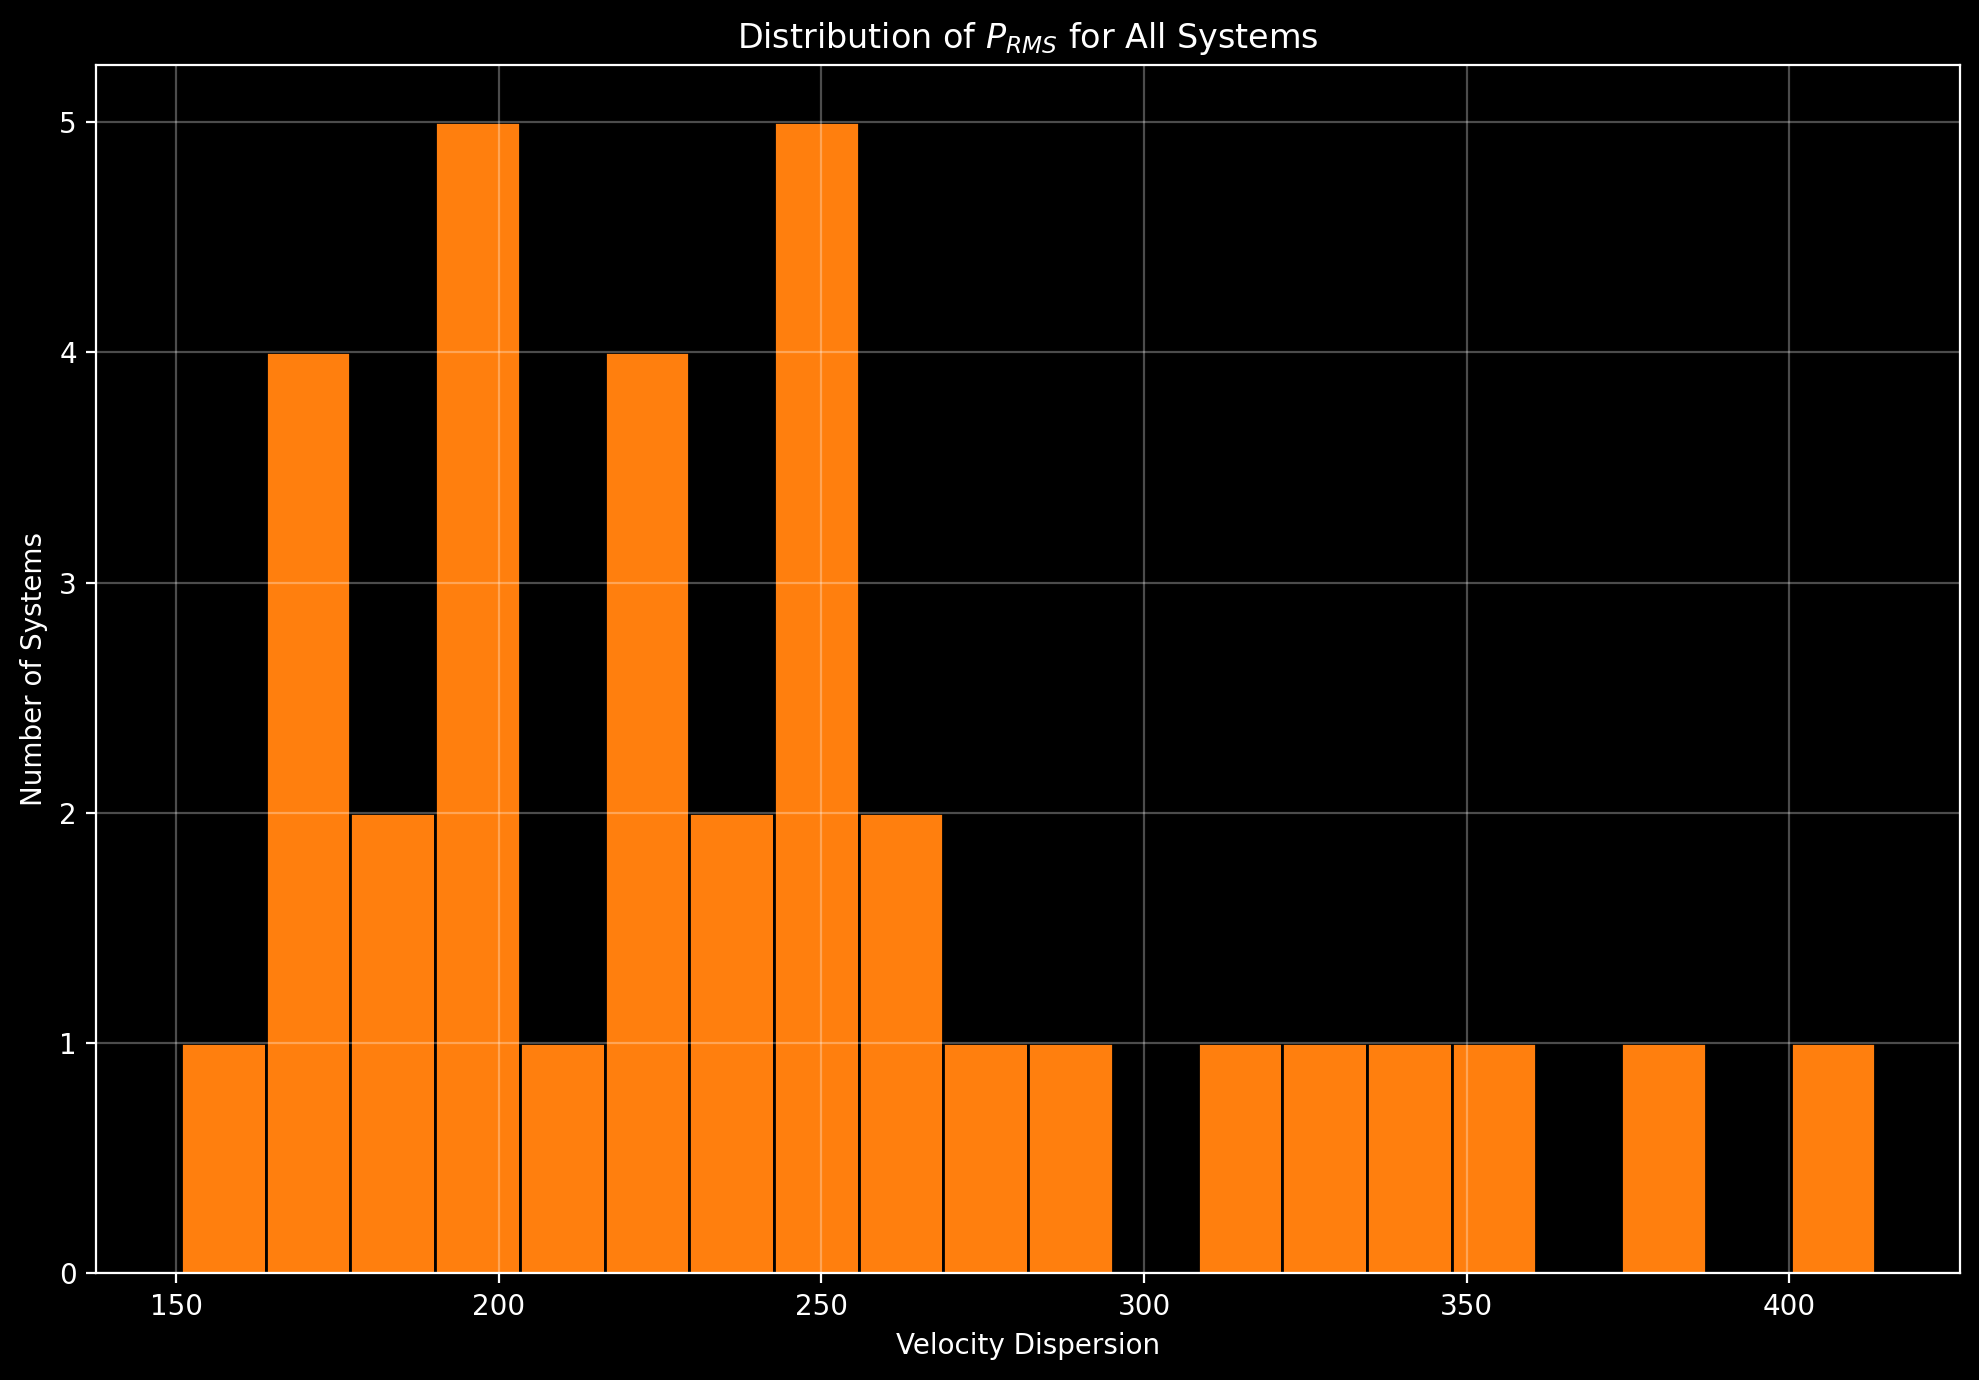

In [ ]:
plt.figure(figsize=(10, 7))